# Lesson 142 · Many-to-many edges: trace where the signal mixes

Student lab · PROVIDED / TODO / CHECK / EXIT. All three learner functions are live in neural computation or the measured paired analysis. Default CPU evidence replay and explicit GPU training are separate.

In [ ]:
# @colab-bootstrap — full GPU execution is separate from default CPU checks.
import os,sys,subprocess
os.environ.update(OMP_NUM_THREADS='1',OPENBLAS_NUM_THREADS='1',MKL_NUM_THREADS='1')
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','pytorch-frame==0.2.3','torch-geometric==2.6.1','relbench==1.1.0','sentence-transformers==3.3.1'])
from pathlib import Path
import base64,hashlib,io,json,zlib
import numpy as np,pandas as pd,torch
from IPython.display import display
RUN_FULL_REPRODUCTION=False
FULL_SEEDS=list(range(5));PREPARED_ROOT=None


In [ ]:
PACKET=base64.b64decode('...')
assert hashlib.sha256(PACKET).hexdigest()=='b3646ea50c35758f0eb1b57860aefe9f850d6deee524dbbfacb5e7ab949fd17b'
DATA=np.load(io.BytesIO(PACKET))
SOURCES=json.loads(zlib.decompress(base64.b64decode('...')))
SOURCE_ROOT=Path('sources/l141');SOURCE_ROOT.mkdir(parents=True,exist_ok=True)
for name,text in SOURCES.items():(SOURCE_ROOT/name).write_text(text)
AUTHOR_SUMMARY={'status': 'COMPLETE', 'arms': {'composite': {'val': {'mean': 3.1335190782566107, 'sample_sd': 0.18500004606483528}, 'test': {'mean': 4.267390072228616, 'sample_sd': 0.08786312240319658}}, 'ordinary': {'val': {'mean': 3.0455827136985762, 'sample_sd': 0.12730044371874816}, 'test': {'mean': 4.418518695279171, 'sample_sd': 0.30575359751103204}}}, 'paired': {'val': {'seed_gaps': [0.10675865834605004, 0.05176152036280816, -0.42489050079682067, -0.1954722056009806, 0.022160704898770527], 'mean': -0.08793636455803451, 'sample_sd': 0.22059298647916928, 'interpretation': 'positive favors composite; seed variation, not independent-query uncertainty'}, 'test': {'seed_gaps': [-0.18530166220246702, 0.23772218633116335, 0.3183780555976064, 0.4745441043586062, -0.08969956883212976], 'mean': 0.15112862305055583, 'sample_sd': 0.2789497922026358, 'interpretation': 'positive favors composite; seed variation, not independent-query uncertainty'}}, 'verified_predictions': 12590, 'unique_runs': 10, 'paper_target': 3.798, 'tolerance': 0.2, 'closeness': 'OUTSIDE_TOLERANCE', 'parameter_counts': {'composite': 10553601, 'ordinary': 20519169}, 'source_artifact_hashes': {'composite-0/result.json': '9af90b85c4adc2fda1b0314faf5524b124ac95d2b49dd02fa4dcaa71031494b2', 'composite-0/predictions.npz': '8e56244e4e358ff6af043e2fbe9c188799637406a4244e73cd14cbccb5f5695c', 'composite-0/sampled_trace.npz': '00a28db35b4022c42aab5528424814a0fdbd818c2ba6070b04414f3ffdd1ec3c', 'composite-1/result.json': 'd6e6f1ceb6da3b924fa3c9332fad4669ff640c190ebd066af564b1992310502e', 'composite-1/predictions.npz': '90994a8c3c080231521419c30d9217c054d6a4c5b8549ae80c460466591b104b', 'composite-1/sampled_trace.npz': '0e9f8ad2d3514805552880c05760d4f8bb432d4e19228dcdb5bc25549e7aa6f2', 'composite-2/result.json': 'df3c7c624fd5da377c5976953d2cdbadd0a29b06b62f55ccb8503b4728a43f48', 'composite-2/predictions.npz': '0ebf03c6b90b08495149a9fa8bc644ec69d5fa543393ec28b29cdb75978e64fc', 'composite-2/sampled_trace.npz': '5592f50ac7785b2fcc8cd02dc8ea6f534e1fa8ab435cbf17318fb8e967f6142a', 'composite-3/result.json': '3266807766158c401f45dcab65cc6215ad38d2968f35a0607604eff0db18e342', 'composite-3/predictions.npz': 'df8950b0513bea403717f3701dc435032ea362600072a6865de81d67a520db4d', 'composite-3/sampled_trace.npz': 'd85d5b03ffd3e580a72d20a3dc16ac92596bb83e9e64e585ac751ded96556d7a', 'composite-4/result.json': 'ad7d0df1476d2514a490437896b82a9dc25d2e563d6a8db5f30dc9f5abbfaebb', 'composite-4/predictions.npz': 'ee8c48b3c94c0a4ed55f948d47cd72c90de2f449d8d7d3260826ee71596defd3', 'composite-4/sampled_trace.npz': '5ec25d691c6b3458a0ace1142e042e742b35b422e4f0fad5442b29e681d41ae2', 'ordinary-0/result.json': 'b3450d2732b3798843fd05a0992ef4bb2a2b431da13face745ee35cfdd09f98e', 'ordinary-0/predictions.npz': '800b3e64997b716b00d0b524d735516c5e4543b1344897971db5e78d68eb0f60', 'ordinary-0/sampled_trace.npz': '3a2a95d3d35943cb649a0270a30793f8cd5ff902b722fed1639963a2190ba4ef', 'ordinary-1/result.json': 'a64944677cf06ac9e3b8deef0959f5c5c84792455940ee5e3343c752f8aa6aff', 'ordinary-1/predictions.npz': 'f37ad94c0e69dd4a1e5f79f284283b4e0cdd426a460d2cc329996172b8fb3e13', 'ordinary-1/sampled_trace.npz': '98c842390f57acebeae2eac05b14b74f1d8f5d62fb4518632bc2b440a47eda74', 'ordinary-2/result.json': 'd25f0885d3d0af2b84784ef29dcbe686379757bdafce0ecccf92defc85ff3a4f', 'ordinary-2/predictions.npz': 'd9d8c32b9b0fe5ff978ce08c5e41df614af9b1ed763afb702ec198dc2357d1bf', 'ordinary-2/sampled_trace.npz': 'c37b7857277ee39903adae8a4e66a254261f891527adf7e8f8b62ca6a332a6ee', 'ordinary-3/result.json': 'd99f0b6c1bb7ff37e8c0d65aca750ac50cced03dcd213863b731edfca4b705f7', 'ordinary-3/predictions.npz': '21db8d7c7bf26af25a8164e25d1229152c06053dabbe07e9bb3ffd00e36c0b31', 'ordinary-3/sampled_trace.npz': '99269decf8ed1ce0457288c526ad3e08397d8f5dff5815b2b29327964b85a682', 'ordinary-4/result.json': 'cffb97c5317298b7ad99ee6fbe60f830f72901c43ad36fc37fc1ae7668efc99d', 'ordinary-4/predictions.npz': 'd30ea3ffd705a31db0ada48ba8b03090c9db4e1264294c188d466f45c2595cbd', 'ordinary-4/sampled_trace.npz': '41604dec8aab5e38d419bde73b5d7fe30aedb76159fc76cc1784e48380e27845'}, 'temporal_query_occurrences': 807790, 'first_batch_nonfinite_gradients': {'composite': {'encoder.encoders.results.encoder.encoder_dict.numerical.weight': 640}, 'ordinary': {'encoder.encoders.results.encoder.encoder_dict.numerical.weight': 512}}, 'historical_training': 'NOT_ESTABLISHED', 'whole_paper': 'NOT_RUN', 'learner': 'PENDING_WRITTEN_DEFENSE'}
AUTHOR_HISTORIES={'composite-0': [{'epoch': 1, 'train_l1': 8.79839898313569, 'val_mae': 4.217469172073192, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.794065907093304, 'val_mae': 4.476522137470539, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.601680687379258, 'val_mae': 3.8330486278495712, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.516985284124644, 'val_mae': 3.729085971804245, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.415094624570575, 'val_mae': 3.426087593634127, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 5.1515994486034, 'val_mae': 3.2564675322196925, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 4.989769261514272, 'val_mae': 3.611038155132082, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.861330520554899, 'val_mae': 3.5293330055598666, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 4.8825138377111115, 'val_mae': 2.972835869747715, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.924444185735778, 'val_mae': 4.014047146799092, 'queries': 7453, 'steps': 15}], 'composite-1': [{'epoch': 1, 'train_l1': 9.02572593308291, 'val_mae': 4.298567370056071, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.867627329689652, 'val_mae': 4.427809309975338, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.58287147079407, 'val_mae': 4.203715763206712, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.492832714157416, 'val_mae': 3.658130256255309, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.337715148294518, 'val_mae': 3.4051409806103097, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 5.085320553087986, 'val_mae': 3.136481409958385, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 4.877160961799957, 'val_mae': 3.1164697698059287, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.804236012549268, 'val_mae': 3.7053348666441464, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 4.878311750842866, 'val_mae': 2.9888765363113516, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.829477887209288, 'val_mae': 3.1868722191952674, 'queries': 7453, 'steps': 15}], 'composite-2': [{'epoch': 1, 'train_l1': 9.071972875783478, 'val_mae': 4.350697674748096, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.891748287053006, 'val_mae': 4.399470623477587, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.574231291983815, 'val_mae': 3.7824673841854852, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.46283281051951, 'val_mae': 3.5029132453138705, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.171487037047561, 'val_mae': 3.4893645097354127, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 4.968805259625852, 'val_mae': 4.247245803258383, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 4.915965726227468, 'val_mae': 4.125542837536646, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.836944000264272, 'val_mae': 3.3916372106166066, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 4.825348889797338, 'val_mae': 3.439764307081979, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.869873053806082, 'val_mae': 3.787767617321843, 'queries': 7453, 'steps': 15}], 'composite-3': [{'epoch': 1, 'train_l1': 8.70168680330752, 'val_mae': 4.177191850767983, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.776204043327415, 'val_mae': 4.518286419105912, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.588713248641138, 'val_mae': 4.010038924105739, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.494814514978407, 'val_mae': 3.6781394945754955, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.281680155258934, 'val_mae': 3.557346308701183, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 5.015663535991931, 'val_mae': 3.168978303005955, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 4.929454419122271, 'val_mae': 3.102628210025703, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.913103564846861, 'val_mae': 3.3948975041936693, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 4.758908182824308, 'val_mae': 4.676636944696277, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.950125578969412, 'val_mae': 3.6155336113078005, 'queries': 7453, 'steps': 15}], 'composite-4': [{'epoch': 1, 'train_l1': 8.965068443523394, 'val_mae': 4.276606916632745, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.844740103958727, 'val_mae': 4.460691940776492, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.624360799437543, 'val_mae': 4.039420817546552, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.539624578576699, 'val_mae': 3.875258748086994, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.488448883355894, 'val_mae': 3.469130913066164, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 5.295270337059969, 'val_mae': 3.348069190979004, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 5.092719111955893, 'val_mae': 3.2116597499223096, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.932205062682634, 'val_mae': 4.112893119619621, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 4.869212300229666, 'val_mae': 3.8641808193527867, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.77538052874999, 'val_mae': 3.359614452331482, 'queries': 7453, 'steps': 15}], 'ordinary-0': [{'epoch': 1, 'train_l1': 8.846847720856468, 'val_mae': 4.227629359085399, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.8100084576593325, 'val_mae': 4.51032078207216, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.618215577104096, 'val_mae': 4.0210593245868775, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.530588878184762, 'val_mae': 3.8618865471166535, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.445843045294267, 'val_mae': 3.561176526331472, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 5.193863182301608, 'val_mae': 3.232214018911541, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 5.033785416916884, 'val_mae': 3.692930032479102, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.966854763240005, 'val_mae': 3.4131282943363734, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 4.842810768763139, 'val_mae': 3.1246045166759706, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.748411751936552, 'val_mae': 3.055797346863017, 'queries': 7453, 'steps': 15}], 'ordinary-1': [{'epoch': 1, 'train_l1': 9.122116889063934, 'val_mae': 4.371703515470068, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.907875645455513, 'val_mae': 4.374716651575041, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.615562738950629, 'val_mae': 4.23857467985185, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.539386352511082, 'val_mae': 3.9670753415298208, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.509340412131874, 'val_mae': 3.926736999211028, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 5.335409425361578, 'val_mae': 3.334097585378684, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 5.1253028079186915, 'val_mae': 3.0730520186618553, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.994738683376826, 'val_mae': 3.5441166537558146, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 4.8852757235408095, 'val_mae': 3.271132551039069, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.749819286940504, 'val_mae': 3.0225504176968645, 'queries': 7453, 'steps': 15}], 'ordinary-2': [{'epoch': 1, 'train_l1': 9.094328166721347, 'val_mae': 4.37245435147741, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.930911071782803, 'val_mae': 4.37770599818819, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.617435229552379, 'val_mae': 4.1064694984960965, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.533321592693568, 'val_mae': 3.9417317484089276, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.286040723052443, 'val_mae': 3.121829336009666, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 5.1919236924856325, 'val_mae': 3.2813547930720657, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 5.075967683331038, 'val_mae': 3.368632338631527, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.929058112997485, 'val_mae': 3.2226845353941322, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 4.837058820770979, 'val_mae': 3.184802610235526, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.754478759890171, 'val_mae': 2.990291175702133, 'queries': 7453, 'steps': 15}], 'ordinary-3': [{'epoch': 1, 'train_l1': 8.696299025801581, 'val_mae': 4.176071482207987, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.821118522329094, 'val_mae': 4.5129440062987305, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.599824800478111, 'val_mae': 3.983153258472104, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.51362700657478, 'val_mae': 3.6414783489250233, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.252559219871161, 'val_mae': 3.264512604080842, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 5.075795569514336, 'val_mae': 3.3757533895865866, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 4.93599718382973, 'val_mae': 3.5177275621341564, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.808260760304539, 'val_mae': 2.916568111210723, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 4.8369312531673305, 'val_mae': 3.0528896857359125, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.736589566886817, 'val_mae': 3.430779064474061, 'queries': 7453, 'steps': 15}], 'ordinary-4': [{'epoch': 1, 'train_l1': 9.118243512169164, 'val_mae': 4.381726865698357, 'queries': 7453, 'steps': 15}, {'epoch': 2, 'train_l1': 5.925771519263297, 'val_mae': 4.351064332135136, 'queries': 7453, 'steps': 15}, {'epoch': 3, 'train_l1': 5.6165689274057575, 'val_mae': 4.171865896073356, 'queries': 7453, 'steps': 15}, {'epoch': 4, 'train_l1': 5.540550610153174, 'val_mae': 3.954309223967548, 'queries': 7453, 'steps': 15}, {'epoch': 5, 'train_l1': 5.439536152332136, 'val_mae': 3.394075971742272, 'queries': 7453, 'steps': 15}, {'epoch': 6, 'train_l1': 5.201736388775258, 'val_mae': 3.25001609320631, 'queries': 7453, 'steps': 15}, {'epoch': 7, 'train_l1': 5.018519793179921, 'val_mae': 3.27529948323109, 'queries': 7453, 'steps': 15}, {'epoch': 8, 'train_l1': 4.9723066142667545, 'val_mae': 3.412195227475826, 'queries': 7453, 'steps': 15}, {'epoch': 9, 'train_l1': 4.8599284655314525, 'val_mae': 3.2553978412885547, 'queries': 7453, 'steps': 15}, {'epoch': 10, 'train_l1': 4.827564848029681, 'val_mae': 3.832380232177102, 'queries': 7453, 'steps': 15}]}


<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Reading guide">
<p class="sequence-eyebrow">Explain the failure before claiming the fix</p>
<p><strong>Reading route.</strong> Count two-layer walks → construct a collision → compare the real networks → limit the conclusion.</p>
<details><summary>Quick prerequisite reminder</summary><p>A synchronous layer reads every node’s old state before producing new states. A collision means different inputs become the same representation. It matters for prediction only when their targets differ. A controlled scalar example can establish this mechanism without establishing its importance in a trained benchmark.</p></details>
</aside>
<!-- sequence-review:end -->



## 1 · A graph can preserve the database while an update loses a distinction

[Lesson 141](https://avistian.github.io/relational/lessons/0141-composite-message-passing.html) built a composite route: source → fact row → destination. It showed how two physical edges can form one model update. Now ask the harder question: **what goes wrong if we treat those edges as two ordinary updates?**

Your tangible win is to trace a message, identify an avoidable return path, and explain what evidence would be needed to blame a benchmark error on that path. This supports our mission of defending relational deep learning with reproducible evidence rather than assuming that a new architecture must help.

A **row** is one database record. Its **primary key** uniquely identifies it. A **foreign key** points to one row in another table. A **many-to-many relationship** allows each entity on either side to relate to several on the other: one driver enters many races, and one race contains many drivers. A junction or **fact table** records each occurrence; one result row refers to a particular driver, race, and constructor. The fact can contain important attributes such as a finishing position. It is not disposable plumbing.

The graph keeps the fact as a node and foreign keys as edges. Keeping these rows and links can preserve the database information. A learned **embedding**, a fixed-width numerical summary of a node, is a different object. Its aggregation can mix distinctions the graph still contains. “Lossless graph conversion” does not imply “lossless message passing.” Primary reading: [RelGNN v2 §§3.1–3.2 and equations 1–3](https://arxiv.org/html/2502.06784v2#S3).







## 2 · Count walks before learning weights

A **message** is a numerical contribution sent along an edge. A **layer** updates all nodes from the previous layer's embeddings; it is synchronous. Updating a fact and immediately using its new value to update a driver inside an ordinary layer would silently change the model.

Start with an exact, deliberately simple linear diagnostic. Let `s` be the source value, `f` the fact value, and `d` the destination value. The graph is `s ↔ f ↔ d`. Each ordinary layer adds the node's previous value to the sum of its neighbors' previous values. The self contribution is often called a **residual** or root term. We use identity weights and no activation to count paths transparently; this is not the trained attention network.

**Predict before revealing:** with `s=2`, `f=1`, `d=3`, what value reaches the destination after two ordinary layers? How much came from the original source?

At layer 1, `f₁=f+s+d` and `d₁=d+f`. At layer 2, `d₂=d₁+f₁=s+2f+2d=10`. The source first arrives at layer 2. The fact contributes twice: it stayed at the fact then moved, or moved to the destination then stayed. The destination also contributes twice: it stayed twice, or traveled `d→f→d`.

This is a walk-counting result under specified weights. It illustrates the paper's redundancy and imbalance arguments. It does not establish that every trained GNN duplicates information with coefficient two: attention, learned transforms, normalization, and root design change those coefficients.

<figure class="route-figure" tabindex="0">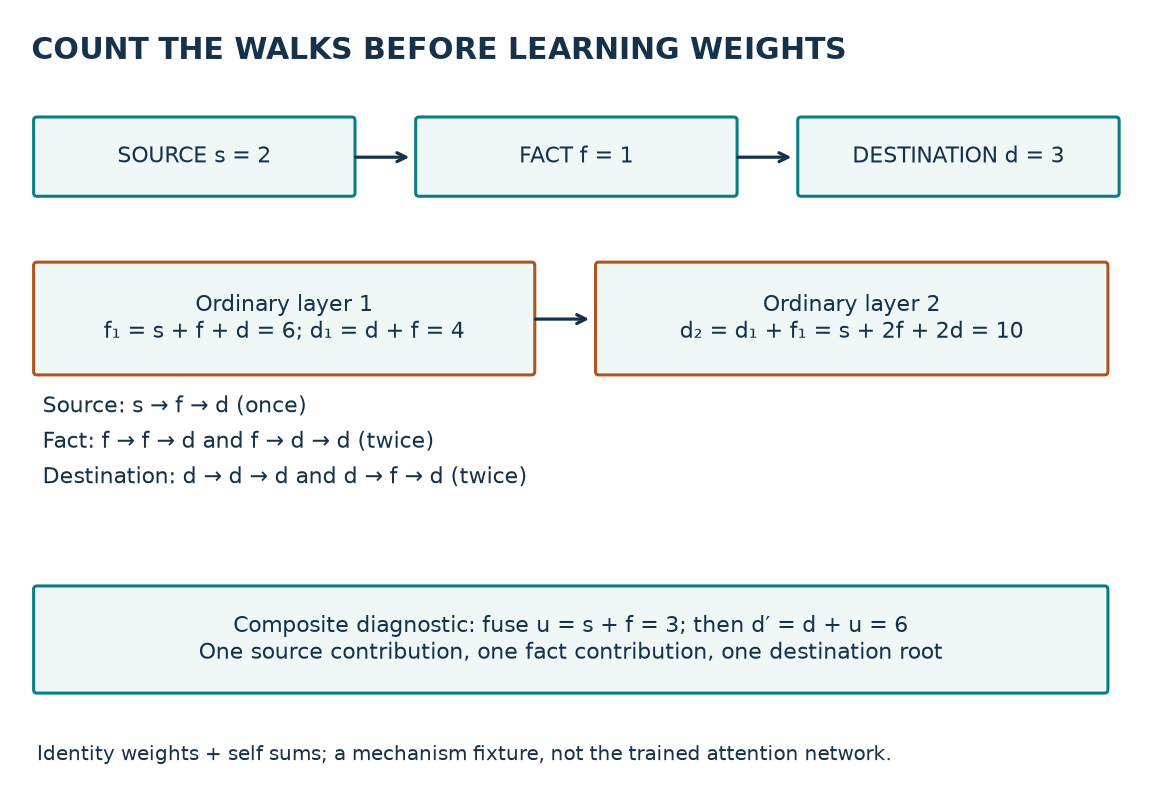<figcaption>Exact linear diagnostic: one source path, two fact paths and two destination paths. Identity weights and self sums differ from the trained attention network. Scroll horizontally on narrow screens.</figcaption></figure>
Baseline s=2,f=1,d=3: ordinary10, composite6. Destination-only input1 produces ordinary2, composite1.

For a transparent composite diagnostic, fuse `u=s+f` for this source–fact–destination route, then update `d′=d+u=6`. There is no `d→f→d` return inside this update. The fact still contributes. Removing the fact altogether would erase event attributes and could collapse repeated events with different times.

**CHECK:** set `s=0,f=0,d=1`. Ordinary output is 2; composite output is 1. Set only `f=1`: ordinary is 2; composite is 1. Set only `s=1`: both are 1. These interventions isolate the coefficient of each input.



## 3 · A hub can mix roles before the destination chooses

A **bridge** fact has two foreign key roles. A **hub** has three or more. A result row connects driver, race, and constructor. If the source is race and the destination is driver, constructor is another role—not necessarily noise. Whether it is useful depends on the target.

Add a third neighbor with scalar value `n`. The same ordinary diagnostic gives `f₁=f+s+d+n`, then `d₂=s+2f+2d+n`. A single shared intermediate representation has mixed the source with the third role before the destination receives it.

**Predict:** compare `(s,n)=(2,8)` and `(8,2)` with `f=1,d=3`. Can the destination's second-layer scalar identify which world it saw?

Both ordinary outputs equal 18. The source-specific composite outputs are 6 and 12. If the target depends on `s`, that ordinary representation has a **collision**: distinct inputs needing distinct predictions became identical. No downstream function of that scalar alone can recover the difference. If the target is instead `s+n`, the two worlds legitimately share the same target, and the collision causes no problem.

<figure class="route-figure" tabindex="0">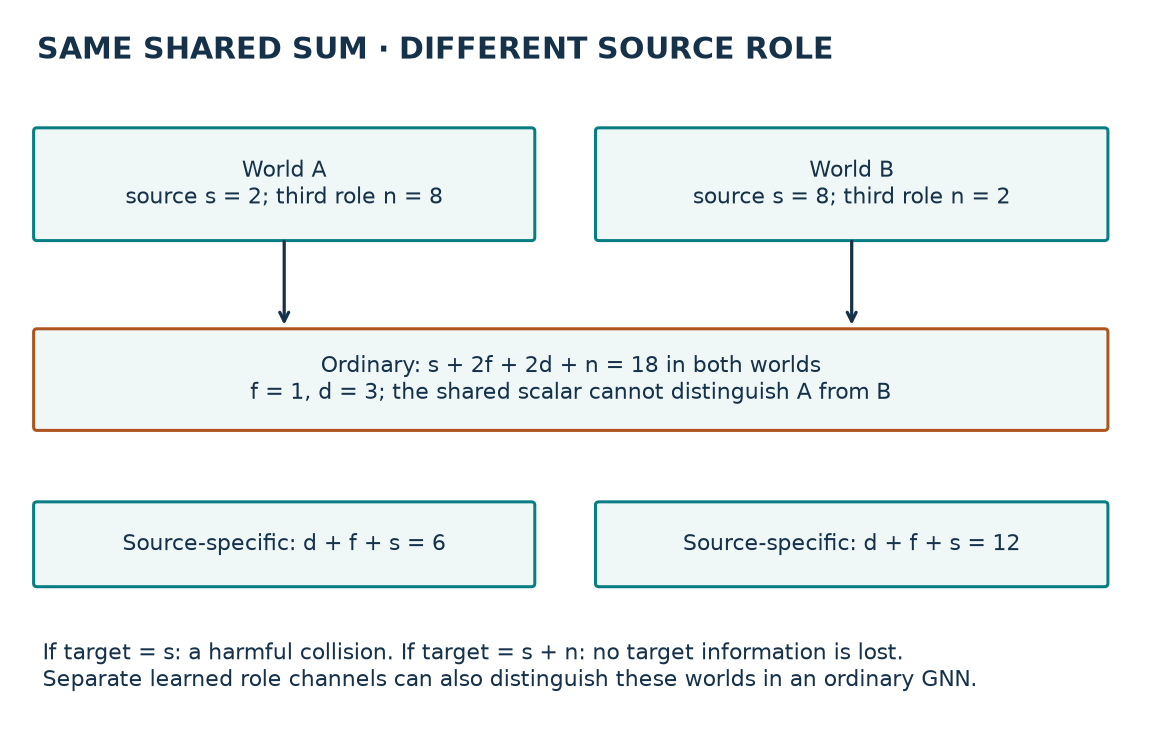<figcaption>Swapping source and third-role values preserves the shared scalar sum. It destroys a source-specific distinction but preserves their total. Scroll horizontally on narrow screens.</figcaption></figure>
Baseline s=2,n=8,f=1,d=3: ordinary18, composite6. Swap s/n: ordinary18, composite12.

The qualification matters. Distinct learned maps per relation, enough hidden width, or separate channel blocks can preserve source roles even with ordinary message passing. Our collision is a proof about a specified equal-weight scalar sum, not an impossibility theorem for heterogeneous GNNs. Conversely, composite routes also compress information; their later route summation can still create collisions.

The paper's motivation is a useful **inductive bias**: an architectural preference for preserving particular relational interactions. It is not a universal ordering of predictive performance. [RelGNN §3.2 and §4.2](https://arxiv.org/html/2502.06784v2#S3.SS2).

**TODO 1 — incoming sums:** implement `edge_sum`. Preserve the destination axis and every trailing feature/head axis. Duplicate destination indices mean sum, not overwrite. The function feeds both neural arms.

**TODO 2 — route fusion:** implement `route_fuse`. Select only the declared source role, sum its incoming values, apply its transform once per fact, and add the transformed fact. Applying a biased source transform before aggregation would repeat the bias when several sources are present and omit it on empty neighborhoods. This function feeds the composite model.



In [ ]:
# TODO: live neural operator
def edge_sum(values,destination,num_destinations):
    raise NotImplementedError("TODO: edge_sum")

In [ ]:
# CHECK: independent arithmetic
def check_edge_sum(fn):
    values=torch.tensor([[2.,3.],[5.,7.],[11.,13.]],requires_grad=True)
    out=fn(values,torch.tensor([1,0,1]),3)
    torch.testing.assert_close(out,torch.tensor([[5.,7.],[13.,16.],[0.,0.]]))
    out.square().sum().backward()
    torch.testing.assert_close(values.grad,torch.tensor([[26.,32.],[10.,14.],[26.,32.]]))
    assert fn(values[:0],torch.empty(0,dtype=torch.long),3).shape==(3,2)
check_edge_sum(edge_sum)

In [ ]:
# TODO: live neural operator
def route_fuse(source,fact,edges,source_transform=None,fact_transform=None):
    raise NotImplementedError("TODO: route_fuse")

In [ ]:
# CHECK: independent arithmetic
def check_fuse(fn):
    source=torch.tensor([[2.],[7.]],requires_grad=True);fact=torch.tensor([[10.],[20.],[30.]],requires_grad=True)
    edges=torch.tensor([[1,0,1],[0,1,2]])
    out=fn(source,fact,edges)
    torch.testing.assert_close(out,torch.tensor([[17.],[22.],[37.]]))
    out.sum().backward();torch.testing.assert_close(source.grad,torch.tensor([[1.],[2.]]))
    torch.testing.assert_close(fact.grad,torch.ones_like(fact))
    torch.testing.assert_close(fn(source,fact,edges[:,:0]),fact)
check_fuse(route_fuse)

## 4 · What the full networks actually compute

An **attention head** weights incoming messages using a destination query and source keys. For each edge, a dot-product score is divided by the square root of the head width. **Softmax** exponentiates scores and divides by their sum over messages with the same destination and head. The resulting nonnegative weights sum to one. Weighted source values are summed; multiple heads are concatenated and projected back to the model width.

Both arms begin with the same kinds of table-specific **row encoders**, neural networks that map heterogeneous columns to 128 numbers. A query-relative time encoder adds information about the difference between the prediction cutoff and a sampled row's event time. Each timestamp is compared with the cutoff of its owning query, not the largest cutoff in the batch.

**Composite arm:** one released RelGNN layer. For each ordered source/fact/destination route, fuse transformed source and fact features, then attend from the destination to those fused messages. Each of four heads produces 128 channels: concatenation has 512 channels, projected to 128. Sum route outputs, normalize each node's channels with LayerNorm, apply ReLU (replace negative values by zero), select queried driver rows, and use a scalar head. The release also updates fact representations from route intermediates. The complete code preserves this behavior.

**Ordinary arm:** two layers of edge-type-specific attention. Each directed foreign key edge and reverse edge gets its own parameters. Every layer reads the old embeddings of all types, sums incoming relation outputs at each destination type, then applies the same kind of node-wise LayerNorm and ReLU. A second layer lets source information traverse the fact to the driver. This is a reasonable course comparator, not the paper's published GNN baseline.

<figure class="route-figure" tabindex="0">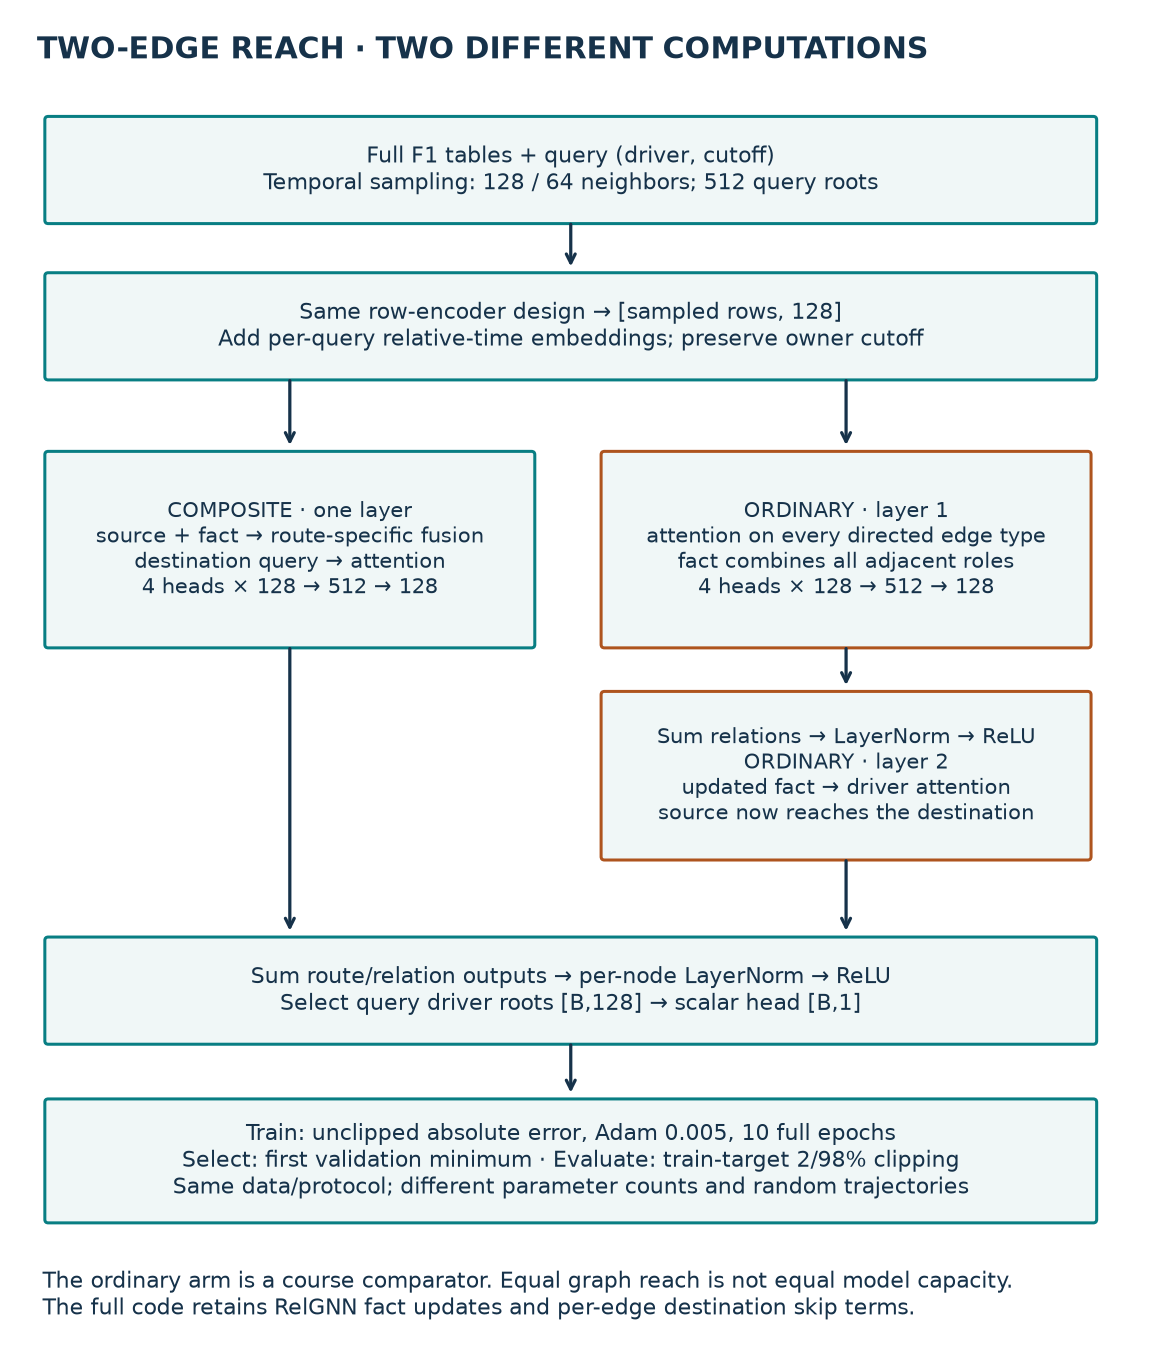<figcaption>Both full networks reach two graph edges. Composite uses one route layer; ordinary uses two edge-attention layers. Shared input design does not imply equal capacity. Scroll horizontally on narrow screens.</figcaption></figure>

Both arms have two-edge reach, 128-channel embeddings, four heads, and the same row/time/head components. The number of attention modules, normalization steps, and parameters differs. Therefore this is an **architecture comparison**, not an experiment that changes only one scalar mechanism. Sampling settings match, but random-number consumption differs, so realized sampled subgraphs are not guaranteed identical across arms.

Inspect the [visible full models](https://avistian.github.io/relational/labs/relkit/relgnn_l142.py), [live functions](https://avistian.github.io/relational/labs/relkit/pathology_l142.py), and [trainer](https://avistian.github.io/relational/labs/_full_l142.py). The portable notebook includes their code inline. The original release serves as an independent composite oracle; ordinary attention is checked against PyG's implementation at identical weights.



In [ ]:
# PROVIDED: visible complete model stage
"""RelGNN source-aligned architecture with explicit composite arithmetic.

MIT upstream cffdb8b54627e92c7dd112c1243dde739c90d35b; see sources/l141/LICENSE.
Selected variant: sum aggregation, no edge attributes, no simplified_MP.
PyG owns parameter containers; the load-bearing forward arithmetic is visible below.
"""


In [ ]:
# PROVIDED: visible complete model stage
# %% Imports and inherited source-aligned operators
import math
from collections import defaultdict
from typing import Any, Dict, List, Optional
import numpy as np
import torch
import torch_frame
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import LayerNorm, PositionalEncoding, MLP
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.nn.conv import TransformerConv, SAGEConv
from torch_geometric.typing import EdgeType, NodeType
from torch_geometric.data import HeteroData
from torch_geometric.nn.module_dict import ModuleDict as RouteModuleDict
def get_atomic_routes(edge_type_list):
    
    src_to_tuples = defaultdict(list)
    for src, rel, dst in edge_type_list:
        if rel.startswith('f2p'):
            if src == dst:
                src = src + '--' + rel
            src_to_tuples[src].append((src, rel, dst))

    atomic_routes_list = []
    get_rev_edge = lambda edge: (edge[2], 'rev_' + edge[1], edge[0])
    for src, tuples in src_to_tuples.items():
        if '--' in src:
            src = src.split('--')[0]
        if len(tuples) == 1:
            _, rel, dst = tuples[0]
            edge = (src, rel, dst)
            atomic_routes_list.append(('dim-dim',) + edge)
            atomic_routes_list.append(('dim-dim',) + get_rev_edge(edge))
        else:
            for _, rel_q, dst_q in tuples:
                for _, rel_v, dst_v in tuples:
                    if rel_q != rel_v:
                        edge_q = (src, rel_q, dst_q)
                        edge_v = (src, rel_v, dst_v)                   
                        atomic_routes_list.append(('dim-fact-dim',) + edge_q + get_rev_edge(edge_v))

    return atomic_routes_list

def destination_softmax(scores, destination, num_destinations):
    """Normalize each head over incoming messages for the same destination."""
    index = destination[:, None].expand_as(scores)
    maxima = scores.new_full((num_destinations, scores.shape[1]), -torch.inf)
    maxima.scatter_reduce_(0, index, scores.detach(), reduce='amax', include_self=True)
    weights = (scores - maxima[destination]).exp()
    totals = scores.new_zeros((num_destinations, scores.shape[1]))
    totals.index_add_(0, destination, weights)
    return weights / (totals[destination] + 1e-16)

def keyed_mae(query_keys, targets, prediction_keys, predictions):
    """A repeated entity at another cutoff is a distinct forecast."""
    q = [tuple(k) for k in query_keys]; p = [tuple(k) for k in prediction_keys]
    y = np.asarray(targets, dtype=float); pred = np.asarray(predictions, dtype=float)
    if not q or len(set(q)) != len(q) or len(set(p)) != len(p) or set(q) != set(p):
        raise ValueError('Require equal unique query-key populations')
    if y.shape != (len(q),) or pred.shape != (len(p),) or not np.isfinite(y).all() or not np.isfinite(pred).all():
        raise ValueError('Require finite one-dimensional targets and predictions')
    lookup = dict(zip(p, pred))
    return float(np.mean(np.abs(y - np.array([lookup[k] for k in q]))))



In [ ]:
# PROVIDED: visible complete model stage
# %% Composite operator: role-specific fact representation then attention
class RelGNNConv(TransformerConv):
    def __init__(self, attn_type, in_channels, out_channels, heads, aggr,
                 simplified_MP=False, bias=True, **kwargs):
        super().__init__(in_channels, out_channels, heads, bias=bias, **kwargs)
        if aggr != 'sum' or simplified_MP:
            raise ValueError('This audited lesson implements the selected full sum variant')
        self.attn_type = attn_type
        if attn_type == 'dim-fact-dim':
            self.aggr_conv = SAGEConv(in_channels, out_channels, aggr=aggr)
        self.simplified_MP = simplified_MP
        self.final_proj = Linear(heads * out_channels, out_channels, bias=bias)
        self.final_proj.reset_parameters()

    def attend(self, source, destination, edges):
        # [nodes, heads, channels/head-output]; here each head outputs 128 channels.
        h, c = self.heads, self.out_channels
        q = self.lin_query(destination).view(-1, h, c)
        k = self.lin_key(source).view(-1, h, c)
        v = self.lin_value(source).view(-1, h, c)
        src, dst = edges
        scores = (q[dst] * k[src]).sum(-1) / math.sqrt(c)
        alpha = destination_softmax(scores, dst, len(destination))
        messages = v[src] * alpha[:, :, None]
        aggregate = edge_sum(messages,dst,len(destination))
        # Source defaults: concatenate heads, add a destination skip, then project.
        joined = aggregate.reshape(len(destination), h*c) + self.lin_skip(destination)
        return self.final_proj(joined)

    def forward(self, x, edge_index, edge_attr=None, return_attention_weights=None):
        if edge_attr is not None or return_attention_weights is not None:
            raise ValueError('Selected experiment does not use edge attributes or attention return flags')
        if self.attn_type == 'dim-dim':
            return self.attend(x[0], x[1], edge_index)
        edge_attn, edge_aggr = edge_index
        source, fact, destination = x
        src, dst = edge_aggr
        intermediate = route_fuse(source,fact,edge_aggr,self.aggr_conv.lin_l,self.aggr_conv.lin_r)
        return self.attend(intermediate, destination, edge_attn), intermediate



In [ ]:
# PROVIDED: visible complete model stage
# %% Route dispatch and route-output sums
def group(xs: List[Tensor], aggr: Optional[str]) -> Optional[Tensor]:
    if len(xs) == 0:
        return None
    elif aggr is None:
        return torch.stack(xs, dim=1)
    elif len(xs) == 1:
        return xs[0]
    elif aggr == "cat":
        return torch.cat(xs, dim=-1)
    else:
        out = torch.stack(xs, dim=0)
        out = getattr(torch, aggr)(out, dim=0)
        out = out[0] if isinstance(out, tuple) else out
        return out
class RelGNN_HeteroConv(torch.nn.Module):

    def __init__(self, convs, aggr: Optional[str]='sum', simplified_MP: Optional[bool]=False):
        super().__init__()
        self.convs = RouteModuleDict(convs)
        self.aggr = aggr
        self.simplified_MP = simplified_MP

    def reset_parameters(self):
        for conv in self.convs.values():
            conv.reset_parameters()

    def forward(self, x_dict, edge_index_dict) -> Dict[NodeType, Tensor]:
        out_dict: Dict[str, List[Tensor]] = {}

        def update(out_dict, dst, out):
            if dst not in out_dict:
                out_dict[dst] = [out]
            else:
                out_dict[dst].append(out)
        for edge_type_info, conv in self.convs.items():
            attn_type = edge_type_info[0]
            if attn_type == 'dim-dim':
                src, rel, dst = edge_type_info[1:]
                x = (x_dict.get(src, None), x_dict.get(dst, None))
                edge_index = edge_index_dict[src, rel, dst]
                out = conv(x, edge_index)
                if self.simplified_MP and out is None:
                    continue
                update(out_dict, dst, out)
            elif attn_type == 'dim-fact-dim':
                edge_attn, edge_aggr = (edge_type_info[1:4], edge_type_info[4:])
                src_attn, _, dst = edge_attn
                src_aggr = edge_aggr[0]
                x = (x_dict[src_aggr], x_dict[src_attn], x_dict[dst])
                edge_index = (edge_index_dict[edge_attn], edge_index_dict[edge_aggr])
                out = conv(x, edge_index)
                if self.simplified_MP and out is None:
                    continue
                out_dst, out_src_attn = out
                update(out_dict, dst, out_dst)
                update(out_dict, src_attn, out_src_attn)
        for key, value in out_dict.items():
            out_dict[key] = group(value, self.aggr)
        if self.simplified_MP:
            for key, value in x_dict.items():
                if key not in out_dict:
                    out_dict[key] = value
        return out_dict

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}(num_relations={len(self.convs)})'


In [ ]:
# PROVIDED: visible complete model stage
# %% Table encoders and query-relative time
class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict
class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


In [ ]:
# PROVIDED: visible complete model stage
# %% Composite stack and node normalization
class RelGNN(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "sum",
        num_model_layers: int = 2,
        num_heads: int = 1,
        simplified_MP=False,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_model_layers):
            conv = RelGNN_HeteroConv(
                {
                    edge_type: RelGNNConv(edge_type[0], (channels, channels), channels, num_heads, aggr=aggr, simplified_MP=simplified_MP)
                    for edge_type in edge_types
                },
                aggr=aggr,
                simplified_MP=simplified_MP,
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_model_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict


In [ ]:
# PROVIDED: visible complete model stage
# %% Whole-model forward pass: table -> time -> routes -> head
class RelGNN_Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_model_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
        atomic_routes=None,
        num_heads=None,
        simplified_MP=False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = RelGNN(
            node_types=data.node_types,
            edge_types=atomic_routes,
            channels=channels,
            aggr=aggr,
            num_model_layers=num_model_layers,
            num_heads=num_heads,
            simplified_MP=simplified_MP,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

    def forward_dst_readout(
        self,
        batch: HeteroData,
        entity_table: NodeType,
        dst_table: NodeType,
    ) -> Tensor:
        if self.id_awareness_emb is None:
            raise RuntimeError(
                "id_awareness must be set True to use forward_dst_readout"
            )
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)
        # Add ID-awareness to the root node
        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
        )

        return self.head(x_dict[dst_table])



In [ ]:
# PROVIDED: visible complete model stage
# %% Course comparison: two ordinary synchronous edge-attention updates
class OrdinaryGNN(torch.nn.Module):
    """Each edge type has its own attention; all updates read the previous layer."""
    def __init__(self,node_types,edge_types,channels=128,num_heads=4):
        super().__init__()
        self.convs=torch.nn.ModuleList([
            RouteModuleDict({edge:RelGNNConv('dim-dim',(channels,channels),channels,num_heads,aggr='sum') for edge in edge_types})
            for _ in range(2)])
        self.norms=torch.nn.ModuleList([torch.nn.ModuleDict({node:LayerNorm(channels,mode='node') for node in node_types}) for _ in range(2)])
    def forward(self,x_dict,edge_index_dict):
        for convs,norms in zip(self.convs,self.norms):
            messages={node:[] for node in x_dict}
            for edge,conv in convs.items():
                src,_,dst=edge
                messages[dst].append(conv((x_dict[src],x_dict[dst]),edge_index_dict[edge]))
            x_dict={node:norms[node](torch.stack(parts).sum(0)).relu() if parts else x_dict[node] for node,parts in messages.items()}
        return x_dict

class OrdinaryModel(RelGNN_Model):
    """Same encoder, temporal encoder and scalar head; replace graph operator only."""
    def __init__(self,**kwargs):
        super().__init__(**kwargs)
        self.gnn=OrdinaryGNN(kwargs['data'].node_types,kwargs['data'].edge_types,kwargs['channels'],kwargs['num_heads'])

class ReferenceOrdinaryModel(OrdinaryModel):
    """Independent PyG propagation oracle at shared weights, no visible edge_sum."""
    def __init__(self,**kwargs):
        super().__init__(**kwargs)
        import types
        def pyg_forward(conv,x,edges):
            return conv.final_proj(TransformerConv.forward(conv,x,edges))
        for layer in self.gnn.convs:
            for conv in layer.values():conv.forward=types.MethodType(pyg_forward,conv)


In [ ]:
# CHECK: both full neural models forward/backward
"""Synthetic whole-model forward/backward; no paper-result claim."""
import pandas as pd
import torch
from torch_frame import stype
from torch_frame.data import Dataset
from torch_geometric.data import HeteroData

def neural_fixture(Model,route_builder):
    torch.set_num_threads(1);torch.manual_seed(141);data=HeteroData();stats={}
    for name,values in [('drivers',[1.,2.,3.,4.]),('results',[3.,5.,9.,10.]),('constructors',[2.,7.,11.,16.])]:
        frame=Dataset(pd.DataFrame({'x':values}),col_to_stype={'x':stype.numerical}).materialize()
        data[name].tf=frame.tensor_frame;stats[name]=frame.col_stats;data[name].num_nodes=4
        data[name].batch=torch.tensor([0,1,0,1]);data[name].n_id=torch.arange(4)
    data['drivers'].seed_time=torch.tensor([864000,1728000]);data['results'].time=torch.tensor([777600,1555200,691200,1468800])
    for dst,fk in [('drivers','driverId'),('constructors','constructorId')]:
        edge=torch.tensor([[0,1,2,3],[0,1,0,1]])
        data['results','f2p_'+fk,dst].edge_index=edge;data[dst,'rev_f2p_'+fk,'results'].edge_index=edge.flip(0)
    model=Model(data,stats,1,128,1,'sum','batch_norm',atomic_routes=route_builder(data.edge_types),num_heads=4)
    model.train();pred=model(data,'drivers').view(-1);assert pred.shape==(2,)
    loss=torch.nn.functional.l1_loss(pred,torch.tensor([3.,5.]));loss.backward();report={}
    for name,part in [('encoder',model.encoder),('time',model.temporal_encoder),('gnn',model.gnn),('head',model.head)]:
        grads=[p.grad for p in part.parameters() if p.grad is not None]
        assert grads and all(torch.isfinite(g).all() for g in grads)
        norm=sum(float(g.square().sum()) for g in grads)**.5;assert norm>0
        report[name]=norm
    return dict(status='PASS',prediction=pred.detach().tolist(),loss=float(loss.detach()),gradient_norms=report,scope='finite synthetic fixture; real missing-value gradients audited separately')

def ordinary_factory(*args,**kwargs):
    kwargs.update(dict(zip(['data','col_stats_dict','num_model_layers','channels','out_channels','aggr','norm'],args)))
    return OrdinaryModel(**kwargs)
fixture_report={name:neural_fixture(model,get_atomic_routes) for name,model in [('composite',RelGNN_Model),('ordinary',ordinary_factory)]}
print(fixture_report)


In [ ]:
# CHECK: independent original composite outputs/gradients
"""Original source differential check, including outputs and all active gradients."""
import contextlib,sys,types
from pathlib import Path
import torch

@contextlib.contextmanager
def original_modules(source_root):
    names=['atomic_routes','relgnn_conv','relgnn_hetero_conv','relgnn_nn','relgnn_model']
    old={n:sys.modules.get(n) for n in names}
    try:
        for name in names:
            m=types.ModuleType(name);sys.modules[name]=m
            exec(compile((Path(source_root)/('examples__'+name+'.py')).read_text(),name,'exec'),m.__dict__)
        yield sys.modules['relgnn_model'].RelGNN_Model,sys.modules['relgnn_conv'].RelGNNConv
    finally:
        for n,m in old.items():
            if m is None:sys.modules.pop(n,None)
            else:sys.modules[n]=m

def check(source_root):
    torch.manual_seed(141);torch.set_num_threads(1)
    errors=[];gradients=0
    with original_modules(source_root) as (_,Original):
        for mode in ['dim-dim','dim-fact-dim']:
            for empty in [False,True]:
                a=RelGNNConv(mode,(4,4),4,2,aggr='sum').double()
                b=Original(mode,(4,4),4,2,aggr='sum').double();b.load_state_dict(a.state_dict())
                x=[torch.randn(n,4,dtype=torch.float64,requires_grad=True) for n in ([3,2] if mode=='dim-dim' else [3,4,2])]
                y=[v.detach().clone().requires_grad_() for v in x]
                e=torch.tensor([[0,1,2],[0,0,1]]) if not empty else torch.empty((2,0),dtype=torch.long)
                edges=e if mode=='dim-dim' else (e,torch.tensor([[0,1,2],[0,1,2]]))
                oa=a(tuple(x),edges);ob=b(tuple(y),edges)
                aa=(oa,) if mode=='dim-dim' else oa;bb=(ob,) if mode=='dim-dim' else ob
                for u,v in zip(aa,bb):
                    torch.testing.assert_close(u,v,atol=1e-12,rtol=1e-12);errors.append(float((u-v).abs().max().detach()))
                sum(u.square().sum() for u in aa).backward();sum(u.square().sum() for u in bb).backward()
                for (ka,pa),(kb,pb) in zip(a.named_parameters(),b.named_parameters()):
                    assert ka==kb
                    if pa.grad is not None:
                        torch.testing.assert_close(pa.grad,pb.grad,atol=1e-11,rtol=1e-11);gradients+=1
                for u,v in zip(x,y):torch.testing.assert_close(u.grad,v.grad,atol=1e-11,rtol=1e-11)
    return dict(status='PASS',cases=4,parameter_gradient_tensors=gradients,max_output_error=max(errors),dtype='float64',scope='operator outputs/input and parameter gradients; empty attention edges included')

parity_report=check(SOURCE_ROOT)
print(parity_report)


## 5 · Make “full reproduction” a checkable claim

Our selected published target is **RelGNN Table 2, `rel-f1/driver-position`: 3.798 test MAE**, averaged over five reported seeds. **MAE**, mean absolute error, averages `|prediction−target|`; its units here are finishing-position units. Lower is better. [Paper Table 2](https://arxiv.org/html/2502.06784v2#S5.T2) · [Pinned release](https://github.com/snap-stanford/RelGNN/tree/cffdb8b54627e92c7dd112c1243dde739c90d35b).

The full archived task contains 7,453 training, 499 validation, and 760 test queries. Each label averages recorded finishing positions in `(cutoff,cutoff+60 days]`. A driver without a future result does not receive a target row. This population is conditional on future participation; it is not a prospective roster of all drivers. Raw-table reconstruction independently checks all labels and query identities.

| Contract | Both fresh arms |
|---|---|
| Data | Complete checksum-pinned F1 archives; fresh materialization shared by the ten fits |
| Inputs | Same inferred column types, GloVe features, full released snapshot and feature statistics |
| Temporal sample | Uniform fanouts 128/64, bidirectional subgraphs, batch 512 |
| Training | Seeds 0–4, ten complete epochs each, Adam 0.005, absolute-error loss |
| Selection | First strict minimum validation MAE; test evaluated after checkpoint freeze |
| Output | Clip evaluation predictions to training-target percentiles 2/98; training is unclipped |
| Comparison | Five paired seed-level error differences; no test-driven tuning |

An **epoch** visits every training query once. Adam is the optimizer that adjusts parameters from loss gradients; 0.005 is its learning rate. Before creating it, an evaluation-mode training batch initializes lazy encoder parameters, matching the documented reconstruction. Validation sampling is stochastic; the selection score and final re-evaluated validation score can differ.

The release does not supply the complete historical optimizer, schedule, initialization sequence, or feature-type cache. These fresh fits use frozen **reconstructed training**, not an exact historical protocol. Lesson 141's five fresh fits missed the ±0.20 descriptive MAE band; we do not retune to erase that finding. Its released checkpoint also required a qualifying-column type reconstruction. L142 trains fresh weights on the same freshly inferred types in both arms; no checkpoint-compatible replay is pooled into this experiment.

**Predict before revealing:** must the composite architecture win on every seed? Would a win prove that destination echoes caused the ordinary model's errors?

| Evidence | Validation MAE | Test MAE | Parameters |
|---|---:|---:|---:|
| Published RelGNN five-seed mean | — | 3.798 | — |
| Fresh composite, five seeds | 3.133519 ± 0.185000 | 4.267390 ± 0.087863 | 10,553,601 |
| Fresh ordinary, five seeds | 3.045583 ± 0.127300 | 4.418519 ± 0.305754 | 20,519,169 |

Mean paired test gap (ordinary − composite): **+0.151129 ± 0.278950 MAE** (sample SD across five seed pairs). Composite versus paper: **OUTSIDE_TOLERANCE**, using the frozen ±0.20 descriptive band. **12,590 held-out predictions** independently aligned and rescored. Historical identity remains **NOT_ESTABLISHED**.

Composite wins **three of five test seed pairs**, while ordinary attention has the lower mean validation MAE. The sign describes these frozen runs only. Neither a win nor a loss identifies the bridge mechanism as the cause; the comparison also changes capacity and normalization depth.

<figure class="route-figure" tabindex="0">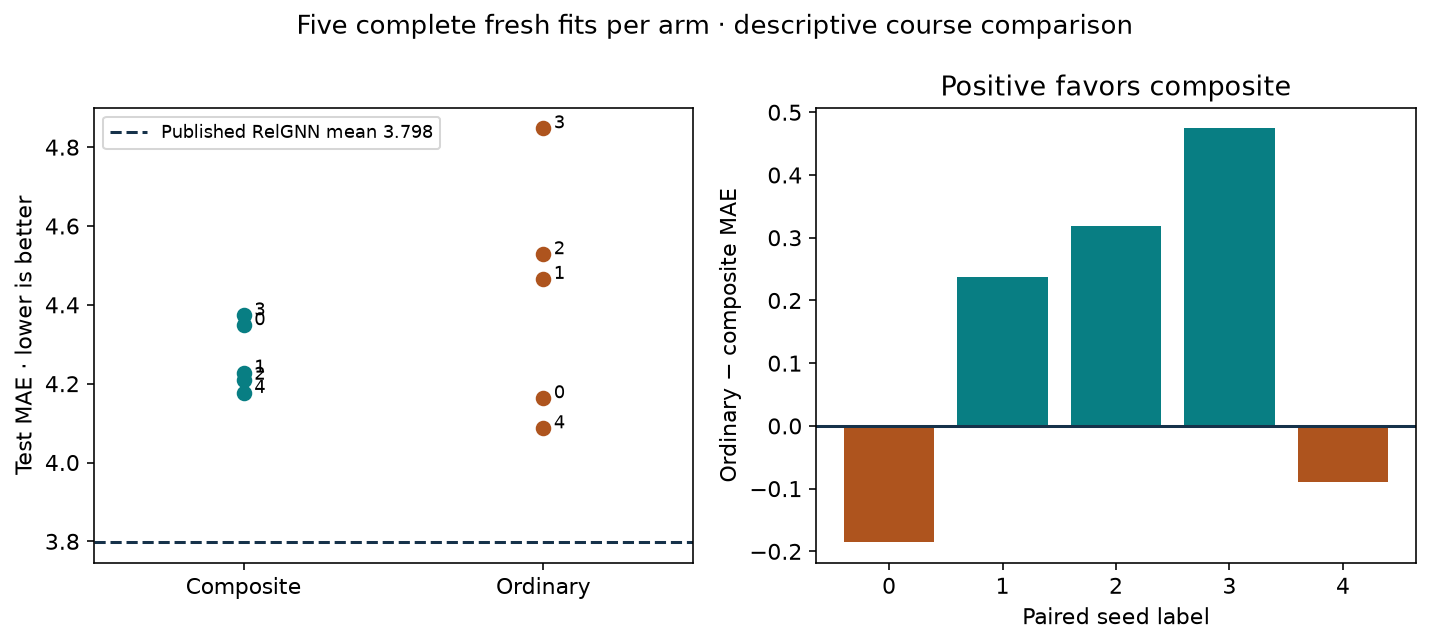<figcaption>Measured test MAE for five complete fits per arm. Seed labels connect the comparison; positive ordinary-minus-composite gaps favor composite. Scroll horizontally on narrow screens.</figcaption></figure>

For seed `j`, define the paired gap as `MAE_ordinary,j − MAE_composite,j`. A positive gap favors composite. Pairing uses the same seed labels and full query identities; it does not make the random trajectories identical. Sample standard deviation describes variation among these five fits. Repeated drivers and dates mean query rows are not independent experimental replicates. We do not manufacture a confidence interval by treating all rows as independent. This F1 test split has also been inspected in earlier lessons: these are fresh training runs, not a fresh held-out test population.

**TODO 3 — keyed paired errors:** implement `paired_loss_gap`. Align both prediction vectors by `(driver,cutoff)`, reject duplicate or missing keys, then subtract per-query absolute errors. Shuffling predictions with their keys must leave the answer unchanged. Your implementation rescoring the author files is a learner exercise, not evidence that you trained those models yourself.

The released numerical row encoder can produce nonfinite gradients for missing-value columns. We retain and count them in both arms. Source parity proves correspondence with the implementation, not healthy optimization. This limitation weakens any causal claim about the graph operator.



In [ ]:
# TODO: live paired measurement
def paired_loss_gap(keys,targets,composite_keys,composite,ordinary_keys,ordinary):
    raise NotImplementedError("TODO: paired_loss_gap")

In [ ]:
def check_pair(fn):
    q=[(1,10),(1,20),(2,10)];y=[1.,5.,8.]
    actual=fn(q,y,q,[2.,3.,8.],q[::-1],[10.,4.,1.])
    np.testing.assert_allclose(actual,[ -1.,-1.,2.]) # ordinary error minus composite error
    for args in [(q,y,q,[2.,3.,8.],q[:-1],[1.,2.]),(q,y,q,[2.,3.,8.],[q[0]]*3,[1.,2.,3.]),(q,y,q,[float('nan'),3.,8.],q,[1.,2.,3.])]:
        try:fn(*args)
        except ValueError:pass
        else:raise AssertionError('Invalid paired population accepted')
check_pair(paired_loss_gap)

In [ ]:
# CHECK: use your keyed function on all primary author predictions.
rows=[];rng=np.random.default_rng(142)
for split in ['val','test']:
    gaps=[]
    for seed in range(5):
        prefix=lambda arm:f'{arm}-{seed}_{split}_'
        ka=list(zip(DATA[prefix('composite')+'entity'],DATA[prefix('composite')+'time']))
        kb=list(zip(DATA[prefix('ordinary')+'entity'],DATA[prefix('ordinary')+'time']))
        y=DATA[prefix('composite')+'target'];np.testing.assert_array_equal(y,DATA[prefix('ordinary')+'target'])
        order=rng.permutation(len(kb))
        gap=paired_loss_gap(ka,y,ka,DATA[prefix('composite')+'pred'],[kb[i] for i in order],DATA[prefix('ordinary')+'pred'][order])
        gaps.append(float(gap.mean()))
        for arm in ['composite','ordinary']:
            score=float(np.abs(y-DATA[prefix(arm)+'pred']).mean());rows.append(dict(arm=arm,seed=seed,split=split,queries=len(y),mae=score))
    np.testing.assert_allclose(gaps,AUTHOR_SUMMARY['paired'][split]['seed_gaps'],atol=1e-12)
for arm in ['composite','ordinary']:
    for split in ['val','test']:
        assert abs(np.mean([r['mae'] for r in rows if r['arm']==arm and r['split']==split])-AUTHOR_SUMMARY['arms'][arm][split]['mean'])<1e-12
for history in AUTHOR_HISTORIES.values():assert len(history)==10 and all(x['queries']==7453 and x['steps']==15 for x in history)
assert sum(r['queries'] for r in rows)==AUTHOR_SUMMARY['verified_predictions']
display(pd.DataFrame(rows))


## 6 · What you can defend now

Read the [complete protocol and evidence ledger](https://avistian.github.io/relational/labs/l142-reproduction.md), [measured summary](https://avistian.github.io/relational/labs/evidence/l142/training.json), and [compact reference](https://avistian.github.io/relational/reference/many-to-many-edge-pathology.html). The default notebook executes neural fixtures and independently scores every author prediction. Its explicit full-data gate trains fresh models in the pinned GPU environment. The validation run of that gate is recorded separately and excluded from the five primary seed means.

The aggregate cloud cap is **US$10**, including preparation, all seeds, failures, and validation. A pilot for each arm precedes the remaining fits; the runner reserves worst-case worker timeouts and retains $3 overhead. If the forecast cannot fit, it stops and labels the unfinished scope. Credits never raise this limit. [Current provider pricing](https://modal.com/pricing).

**EXIT — write before checking:** draw a driver–result–race route with a constructor neighbor. Derive the destination return term for our linear diagnostic. Construct two inputs that collide under that diagnostic but have different source-specific targets. Then explain why a full-data MAE difference does not prove this collision caused the difference in trained networks. Name one control you would add: capacity matching, controlled normalization depth, fixed sampled subgraphs, or a narrowly defined operator intervention.

Write your defense before consulting the reference.

Author checks leave learner status **PENDING_WRITTEN_DEFENSE**. Historical training identity remains **NOT_ESTABLISHED**; the whole paper is **NOT_RUN**. Live Colab and deployment are **NOT_CHECKED** unless separately recorded. Ask the teaching agent follow-up questions, or paste your derivation and defense for feedback. Lesson 143 will build on this distinction between a runnable RelGNN experiment and a defensible reproduction claim.


<!-- sequence-next:start -->
**Carry this forward.** Carry both the mechanism and its limits into Lesson 143: reproducing a model requires checking feature meaning, training history and query identity as well as the score. [Continue to Lesson 143](https://avistian.github.io/relational/lessons/0143-relgnn-reproduction.html).
<!-- sequence-next:end -->


## Full execution code

The preprocessing and trainer below run complete task queries. The gate is off by default. Source files embedded above are differential references. Model, learner functions and trainer remain visible and executable inline. Use a fresh output directory and the pinned environment; see the protocol for the aggregate budget.

In [ ]:
# PROVIDED: source graph construction and query inputs
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )


class LinkTrainTableInput(NamedTuple):
    r"""Training table input for link prediction.

    - src_nodes is a Tensor of source node indices.
    - dst_nodes is PyTorch sparse tensor in csr format.
        dst_nodes[src_node_idx] gives a tensor of destination node
        indices for src_node_idx.
    - num_dst_nodes is the total number of destination nodes.
        (used to perform negative sampling).
    - src_time is a Tensor of time for src_nodes
    """

    src_nodes: Tuple[NodeType, Tensor]
    dst_nodes: Tuple[NodeType, Tensor]
    num_dst_nodes: int
    src_time: Optional[Tensor]


def get_link_train_table_input(
    table: Table,
    task: RecommendationTask,
) -> LinkTrainTableInput:
    r"""Get the training table input for link prediction."""

    src_node_idx: Tensor = torch.from_numpy(
        table.df[task.src_entity_col].astype(int).values
    )
    exploded = table.df[task.dst_entity_col].explode()
    coo_indices = torch.from_numpy(
        np.stack([exploded.index.values, exploded.values.astype(int)])
    )
    sparse_coo = torch.sparse_coo_tensor(
        coo_indices,
        torch.ones(coo_indices.size(1), dtype=bool),
        (len(src_node_idx), task.num_dst_nodes),
    )
    dst_node_indices = sparse_coo.to_sparse_csr()

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    return LinkTrainTableInput(
        src_nodes=(task.src_entity_table, src_node_idx),
        dst_nodes=(task.dst_entity_table, dst_node_indices),
        num_dst_nodes=task.num_dst_nodes,
        src_time=time,
    )


In [ ]:
# PROVIDED: full frozen trainer
"""Full released-checkpoint replay and explicitly reconstructed fresh training.

Reconstruction: five seeds, ten complete epochs, Adam .005, L1, first validation
minimum. These choices are frozen course choices; historical training is unreleased.
"""
import hashlib,json,time,copy
from pathlib import Path
import numpy as np
import torch
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything
from torch_frame.config import TextEmbedderConfig
from relbench.datasets import get_dataset
from relbench.tasks import get_task
from relbench.modeling.utils import get_stype_proposal

ARCHIVES={'db.zip':'ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482','tasks/driver-position.zip':'775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e'}
CHECKPOINT_REVISION='321e6f6e7af5d7546b637f147783fc28ab5d4a7a'
CONFIG=dict(num_model_layers=1,channels=128,aggr='sum',num_heads=4)



In [ ]:
# PROVIDED: full frozen trainer
def sha(path):
    h=hashlib.sha256()
    with Path(path).open('rb') as f:
        while chunk:=f.read(8*1024*1024):h.update(chunk)
    return h.hexdigest()



In [ ]:
# PROVIDED: full frozen trainer
def materialize(root,source_root):
    """Fresh full test-cutoff database and released GloVe row materialization."""
    import urllib.request,zipfile,importlib.metadata as md
    from sentence_transformers import SentenceTransformer
    from huggingface_hub import hf_hub_download
    root=Path(root);root.mkdir(parents=True,exist_ok=False);seed_everything(42);torch.set_num_threads(1)
    for name,digest in ARCHIVES.items():
        target=root/'cache'/name;target.parent.mkdir(parents=True,exist_ok=True)
        urllib.request.urlretrieve('https://relbench.stanford.edu/download/rel-f1/'+name,target)
        assert sha(target)==digest
        with zipfile.ZipFile(target) as z:z.extractall(root/'unpacked')
    dataset=get_dataset('rel-f1');dataset.cache_dir=str(root/'unpacked');dataset.get_db.cache_clear();db=dataset.get_db()
    # Fail closed if installed preprocessing differs from the vendored release.
    import relbench.modeling.graph as graph,relbench.modeling.nn as nn,relbench.modeling.utils as utils
    source_checks={}
    for module,name in [(graph,'graph'),(nn,'nn'),(utils,'utils')]:
        expected=Path(source_root)/f'relbench__modeling__{name}.py'
        source_checks[name]=Path(module.__file__).read_bytes()==expected.read_bytes()
    assert all(source_checks.values()),source_checks
    types=get_stype_proposal(db)
    text=SentenceTransformer('sentence-transformers/average_word_embeddings_glove.6B.300d',revision='e5e8fec6971be8960cfaa853a77a6ddc62a265d7',device='cpu')
    def embed(strings):return text.encode(strings,convert_to_tensor=True)
    data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256),cache_dir=str(root/'materialized'))
    # Independent FK reconstruction from table rows, including missing references.
    fk_edges=0
    for table_name,table in db.table_dict.items():
        for column,parent in table.fkey_col_to_pkey_table.items():
            df=db.table_dict[parent].df;pk=db.table_dict[parent].pkey_col
            lookup={int(v):i for i,v in enumerate(df[pk])}
            expected={(i,lookup[int(v)]) for i,v in enumerate(table.df[column]) if not __import__('pandas').isna(v)}
            actual=set(map(tuple,data[(table_name,'f2p_'+column,parent)].edge_index.numpy().T))
            assert actual==expected,(table_name,column);fk_edges+=len(actual)
    torch.save((data,stats),root/'graph.pt')
    checkpoint=hf_hub_download('tianlangchen/RelGNN','rel-f1_driver-position.pth',revision=CHECKPOINT_REVISION)
    import shutil;shutil.copyfile(checkpoint,root/'released.pth')
    info=dict(graph_sha256=sha(root/'graph.pt'),checkpoint_sha256=sha(root/'released.pth'),checkpoint_revision=CHECKPOINT_REVISION,
        preprocessing='FRESH full released snapshot; seed42; pinned GloVe',archives=ARCHIVES,source_checks=source_checks,
        rows={k:len(t) for k,t in db.table_dict.items()},fk_edges=fk_edges,edges=sum(e.shape[1] for e in data.edge_index_dict.values()),
        routes=[list(r) for r in get_atomic_routes(data.edge_types)],packages={k:md.version(k) for k in ['torch','torch-geometric','pytorch-frame','relbench','numpy','pandas','sentence-transformers','pyg-lib']})
    (root/'prepared.json').write_text(json.dumps(info,indent=2));return info



In [ ]:
# PROVIDED: full frozen trainer
def full_run(output,prepared_root,source_root,seed=0,replay=False,arm="composite"):
    """All query rows are used. Test is opened only after validation selection."""
    assert arm in ['composite','ordinary'] and not replay
    start=time.perf_counter();torch.set_num_threads(1);seed_everything(42 if replay else seed)
    out=Path(output);out.mkdir(parents=True,exist_ok=False);root=Path(prepared_root)
    prepared=json.loads((root/'prepared.json').read_text());assert sha(root/'graph.pt')==prepared['graph_sha256']
    for name,digest in ARCHIVES.items():assert sha(root/'cache'/name)==digest
    data,stats=torch.load(root/'graph.pt',weights_only=False)
    dataset=get_dataset('rel-f1');dataset.cache_dir=str(root/'unpacked');dataset.get_db.cache_clear()
    task=get_task('rel-f1','driver-position');task.cache_dir=str(root/'unpacked'/'driver-position');task.get_table.cache_clear()
    train=task.get_table('train');clip=np.percentile(train.df[task.target_col].to_numpy(),[2,98]).tolist()
    device='cuda' if torch.cuda.is_available() else 'cpu'
    kwargs=dict(data=data,col_stats_dict=stats,out_channels=1,norm='batch_norm',atomic_routes=get_atomic_routes(data.edge_types),**CONFIG)
    model=(RelGNN_Model if arm=="composite" else OrdinaryModel)(**kwargs).to(device)
    # Initial lazy columns must be materialized before a new optimizer is created.
    def loader(split):
        table=task.get_table(split,mask_input_cols=False)
        input_table=table
        if split=='test':
            from relbench.base import Table
            input_table=Table(df=table.df.drop(columns=[task.target_col]),fkey_col_to_pkey_table=table.fkey_col_to_pkey_table,pkey_col=table.pkey_col,time_col=table.time_col)
        inp=get_node_train_table_input(table=input_table,task=task)
        return NeighborLoader(data,num_neighbors=[128,64],time_attr='time',input_nodes=inp.nodes,input_time=inp.time,transform=inp.transform,subgraph_type='bidirectional',batch_size=512,temporal_strategy='uniform',shuffle=split=='train',num_workers=0),table
    # Replay construction order matches source: val loader, test loader, model initialization.
    # Constructors do not sample; seed reset below matches original parameter RNG consumption.
    val_loader,val_table=loader('val')
    train_loader,_=loader('train') if not replay else (None,None)
    audit=dict(query_occurrences=0,timestamped_node_occurrences=0,future_violations=0);trace={};grad_norm=None;gradient_health=None
    def audit_batch(batch):
        cut=batch[task.entity_table].seed_time
        audit['query_occurrences']+=len(cut)
        for name,times in batch.time_dict.items():
            owners=batch[name].batch;bad=int((times>cut[owners]).sum());audit['future_violations']+=bad
            audit['timestamped_node_occurrences']+=len(times)
            assert bad==0,'Future node relative to owning query'
        if not trace:
            trace['cutoffs']=cut.cpu().numpy()
            for name,times in batch.time_dict.items():
                trace[name+'_times']=times.cpu().numpy();trace[name+'_owners']=batch[name].batch.cpu().numpy()
    def evaluate(dl,table,original=None):
        model.eval();parts=[];ids=[];max_error=0.
        with torch.no_grad():
            for batch in dl:
                audit_batch(batch);ids.append(batch[task.entity_table].input_id.cpu().numpy());batch=batch.to(device)
                p=model(batch,task.entity_table).view(-1)
                if original is not None:
                    q=original(batch,task.entity_table).view(-1)
                    error=float((p-q).abs().max());max_error=max(max_error,error)
                    torch.testing.assert_close(p,q,atol=2e-4,rtol=2e-4)
                parts.append(p.clamp(*clip).cpu().numpy())
        ids=np.concatenate(ids);pred=np.concatenate(parts);assert np.array_equal(np.sort(ids),np.arange(len(table)))
        frame=table.df;entity=frame[task.entity_col].to_numpy(dtype=np.int64)
        times=(frame[task.time_col].astype('int64')//10**9).to_numpy();target=frame[task.target_col].to_numpy()
        keys=list(zip(entity,times));predkeys=[keys[i] for i in ids]
        score=keyed_mae(keys,target,predkeys,pred)
        aligned=np.empty_like(pred);aligned[ids]=pred
        assert abs(score-task.evaluate(aligned,table)['mae'])<1e-10
        return dict(mae=score,entity=entity,time=times,target=target,pred=aligned,max_original_error=max_error)
    history=[];best=float('inf');best_epoch=None
    if replay:
        assert sha(root/'released.pth')==prepared['checkpoint_sha256']
        model.load_state_dict(torch.load(root/'released.pth',map_location=device,weights_only=False))
        # Model creation above matches release seed42; checkpoint fills every parameter.
    else:
        model.eval()
        with torch.no_grad():model(next(iter(train_loader)).to(device),task.entity_table)
        optimizer=torch.optim.Adam(model.parameters(),lr=.005)
        for epoch in range(1,11):
            model.train();total=0.;seen=0;steps=0
            for batch in train_loader:
                audit_batch(batch)
                assert np.array_equal(batch[task.entity_table].y.numpy(),train.df[task.target_col].to_numpy()[batch[task.entity_table].input_id.numpy()])
                batch=batch.to(device);optimizer.zero_grad()
                p=model(batch,task.entity_table).view(-1);y=batch[task.entity_table].y
                loss=torch.nn.functional.l1_loss(p,y);assert bool(torch.isfinite(loss));loss.backward()
                if grad_norm is None:
                    grad_norm=float(sum(v.grad.square().sum() for v in model.parameters() if v.grad is not None).sqrt())
                    gradient_health={name:int((~torch.isfinite(v.grad)).sum()) for name,v in model.named_parameters() if v.grad is not None and not torch.isfinite(v.grad).all()}
                optimizer.step();total+=float(loss.detach())*len(y);seen+=len(y);steps+=1
            assert seen==len(train)
            metric=evaluate(val_loader,val_table)['mae']
            history.append(dict(epoch=epoch,train_l1=total/seen,val_mae=metric,queries=seen,steps=steps))
            if metric<best:
                best=metric;best_epoch=epoch;torch.save(model.state_dict(),out/'selected.pt')
            (out/'progress.json').write_text(json.dumps(history,indent=2))
            print('seed',seed,'epoch',epoch,'val',metric,flush=True)
        model.load_state_dict(torch.load(out/'selected.pt',map_location=device,weights_only=False))
    # Compare all held-out raw outputs with original architecture at identical weights/batches.
    with original_modules(source_root) as (Original,_):
        if arm=="ordinary":Original=ReferenceOrdinaryModel
        # Constructing the parity oracle must not change neighborhood sampling RNG.
        with torch.random.fork_rng(devices=[torch.cuda.current_device()] if torch.cuda.is_available() else []):
            original=Original(**kwargs).to(device);original.load_state_dict(model.state_dict());original.eval()
        # Original replay samples test first and never consumes validation sampling RNG.
        test_loader,test_table=loader('test')
        scores={};arrays={}
        for split,dl,table in [('test',test_loader,test_table),('val',val_loader,val_table)]:
            ev=evaluate(dl,table,original);scores[split]={'mae':ev.pop('mae'),'max_original_error':ev.pop('max_original_error')}
            for k,v in ev.items():arrays[split+'_'+k]=v
    np.savez_compressed(out/'predictions.npz',**arrays);np.savez_compressed(out/'sampled_trace.npz',**trace)
    result=dict(status='COMPLETE',arm=arm,parameter_count=sum(p.numel() for p in model.parameters()),first_batch_nonfinite_gradients=gradient_health,kind='RELEASED_CHECKPOINT_REPLAY' if replay else 'RECONSTRUCTED_TRAINING',seed=42 if replay else seed,
        epochs=0 if replay else 10,history=history,best_epoch=best_epoch,selection_mae=None if replay else best,scores=scores,
        count={'train':len(train),'val':len(val_table),'test':len(test_table)},clip=clip,config=CONFIG,gradient_norm=grad_norm,
        graph_sha256=prepared['graph_sha256'],checkpoint_sha256=prepared['checkpoint_sha256'] if replay else sha(out/'selected.pt'),
        temporal_audit=audit,seconds=time.perf_counter()-start,paper_target=3.798,historical_training='NOT_ESTABLISHED')
    (out/'result.json').write_text(json.dumps(result,indent=2));return result


In [ ]:
# Full named task and course comparison; explicit GPU execution.
if RUN_FULL_REPRODUCTION:
    import importlib.metadata as md
    for name,version in {'torch':'2.5.1','torch-geometric':'2.6.1','pytorch-frame':'0.2.3','relbench':'1.1.0','numpy':'1.26.4','pandas':'2.2.3','sentence-transformers':'3.3.1'}.items():
        assert md.version(name).split('+')[0]==version,(name,'requires pinned runtime')
    assert torch.cuda.is_available(),'Pinned GPU environment required'
    prepared=Path(PREPARED_ROOT) if PREPARED_ROOT else Path('l142-prepared')
    if PREPARED_ROOT is None:materialize(prepared,SOURCE_ROOT)
    fresh_results=[full_run(Path('l142-runs')/f'{arm}-{seed}',prepared,SOURCE_ROOT,seed,arm=arm) for arm in ['composite','ordinary'] for seed in FULL_SEEDS]
    print('Full selected execution complete; historical training NOT_ESTABLISHED')
else:print('Default lane: full fresh training NOT_RUN; author files independently rescored.')


In [ ]:
report=dict(status='PASS',predictions=sum(r['queries'] for r in rows),fixtures=fixture_report,operator=parity_report,full_training='RUN' if RUN_FULL_REPRODUCTION else 'NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')
Path('l142-report.json').write_text(json.dumps(report,indent=2))
print(report)